# Colocalisation heatmap
Creates a 2D heatmap showing frequency of paired displacements for linked kymograph traces.  Input displacement files are generated with [colocalisation-analysis-over-time scripts](../colocalisation-analysis-over-time/).  

In [1]:
# Importing libraries
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
# Parameters
input_path = './examples/input/' # Path to folder containing CSVs to process
output_path = './examples/output/' # Path to folder in which to save output
c_lim = [0,100] # Range for colourmap

In [3]:
def collect_data(input_path):
    dists = None

    n_tracks_1 = 0
    n_tracks_2 = 0

    for filename in [name for name in os.listdir(input_path) if 'displacements.csv' in name]:
        curr_dists = np.genfromtxt(input_path+filename, delimiter=',')
        
        if np.isnan(curr_dists[0][0]):
            curr_dists = curr_dists[1::]
        if dists is None:
            dists = curr_dists
        else:
            dists = np.append(dists,curr_dists,0)
        
        n_tracks_1 = n_tracks_1 + len(np.unique(curr_dists[:,1]))
        n_tracks_2 = n_tracks_2 + len(np.unique(curr_dists[:,2]))
        
    return (dists, n_tracks_1, n_tracks_2)


def create_plot(output_path, c_lim, dists, n_tracks_1, n_tracks_2):
    # Creating heatmap    
    ax_min = np.floor(min(min(dists[:,7]),min(dists[:,8]))/10)*10
    ax_max = np.ceil(max(max(dists[:,7]),max(dists[:,8]))/10)*10
    n_bins = int(abs(ax_max)+abs(ax_min))
    heatmap, xedges, yedges = np.histogram2d(dists[:,7], dists[:,8], range=[[ax_min,ax_max],[ax_min,ax_max]],bins=n_bins)
    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

    # Updating axes
    plt.imshow(heatmap.T, extent=extent, origin='lower')
    plt.set_cmap('magma_r')
    ax = plt.gca()
    ax.set_xticks(xedges[0::10])
    ax.set_yticks(yedges[0::10])
    plt.clim(c_lim)
    plt.xlabel('Displacement 1 (px)')
    plt.ylabel('Displacement 2 (px)')
    
    # Saving as png and svg
    N = len(dists[:,8])
    plt.savefig(output_path+"Displacement_hist_(N="+str(N)+")_plot.png")
    plt.savefig(output_path+"Displacement_hist_(N="+str(N)+")_plot.svg")
    plt.show()

    # Displaying summary information
    print("N = %i"%N)
    print("N tracks 1 (red) = %i"%n_tracks_1)
    print("N tracks 2 (green) = %i"%n_tracks_2)


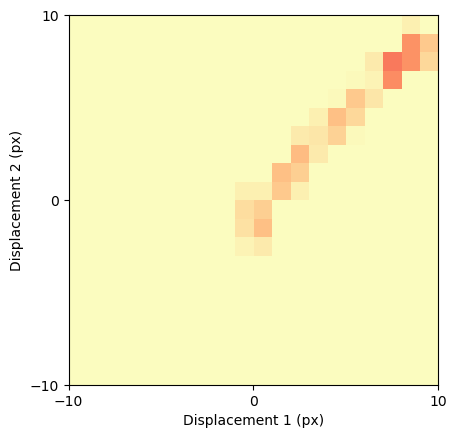

N = 290
N tracks 1 (red) = 2
N tracks 2 (green) = 2


In [4]:
(dists, n_tracks_1, n_tracks_2) = collect_data(input_path)
create_plot(output_path, c_lim, dists, n_tracks_1, n_tracks_2)